# Step 4b — CIMIS station cross-check

Spec: `CLAUDE.md` §6 Step 4b, added 2026-09-16 after `EXHIBIT.md` was first written, once an app
key became available. Step 4 measured how far the four gridded rainfall products disagree with
each other (median 28.5 mm for the same field). It could not say whether any of them is right.
This step compares them against ground stations.

- Station daily precipitation for **9–14 March 2023** (the event) and **4–16 January 2023**
  (a second data point), plus **full calendar 2022 and 2023 at one station** as a units sanity
  check of the kind that caught the CPC error.
- Each product is extracted **at the station's own coordinates**, not at unit centroids.
- Differences are reported absolute and as a percentage of the station total.

**What this cannot do:** stations are sparse and none sits on a strawberry field, so this
establishes absolute accuracy at a handful of points, not product accuracy over the units.

Raw JSON is downloaded by `notebooks/download_cimis.py` into `data/raw/cimis/`, with provenance
in `SOURCE.md`. The app key is read from the environment or a gitignored file; it is never
printed here and never committed.

**CHECKPOINT:** the station table, the per-product comparison for both events, and the verdict.

In [1]:
import json
from pathlib import Path

import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C

ee.Initialize(project=C.EE_PROJECT)

CIMIS = C.RAW / "cimis"
EVENT = ("2023-03-09", "2023-03-15")   # end is exclusive in ee.filterDate; window is 9-14 March
JAN = ("2023-01-04", "2023-01-17")     # 4-16 January
EVENT_DAYS = ("2023-03-09", "2023-03-14")
JAN_DAYS = ("2023-01-04", "2023-01-16")


def load(name):
    return json.loads((CIMIS / name).read_text(encoding="utf-8"))


def decimal(s):
    import re
    m = re.search(r"/\s*(-?\d+\.\d+)", s or "")
    return float(m.group(1)) if m else None


stations_raw = load("stations.json")["Stations"]
st = pd.DataFrame([{
    "station": int(s["StationNbr"]), "name": s["Name"].strip(), "city": (s.get("City") or "").strip(),
    "county": (s.get("County") or "").strip(), "active": str(s.get("IsActive")).lower() == "true",
    "elev_ft": pd.to_numeric(s.get("Elevation"), errors="coerce"),
    "ground_cover": (s.get("GroundCover") or "").strip(),
    "siting": " ".join((s.get("SitingDesc") or "").split()),
    "lat": decimal(s.get("HmsLatitude", "")), "lon": decimal(s.get("HmsLongitude", "")),
} for s in stations_raw])
st = st.dropna(subset=["lat", "lon"])
st["elev_m"] = st.elev_ft * 0.3048

# distance from each station to the nearest analysis unit, in California Albers
units = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
units = units[units.is_unit.astype(bool)]
u = gpd.GeoDataFrame(units, geometry=gpd.points_from_xy(units.lon, units.lat),
                     crs="EPSG:4326").to_crs(C.GRID_CRS)
s_all = gpd.GeoDataFrame(st, geometry=gpd.points_from_xy(st.lon, st.lat),
                         crs="EPSG:4326").to_crs(C.GRID_CRS)
uu = u.geometry.union_all()
st["km_to_nearest_unit"] = [g.distance(uu) / 1000 for g in s_all.geometry]

# Distance to the Pacific. The outer boundary of the dissolved California county set is the
# state outline; for stations in these counties the nearest segment of it is the coast.
from shapely.geometry import shape

ca = (ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.eq("STATEFP", "06"))
      .geometry().dissolve(maxError=500))
coast = gpd.GeoSeries([shape(ca.getInfo()).boundary], crs="EPSG:4326").to_crs(C.GRID_CRS).iloc[0]
st["km_to_coast"] = [g.distance(coast) / 1000 for g in s_all.geometry]

print(f"CIMIS stations retrieved: {len(st)} with coordinates | "
      f"counties: {sorted(st.county.unique())}")
print(f"n units = {len(units)} | datasets: CIMIS Web API (data/raw/cimis/SOURCE.md), "
      f"{C.UNITS_ASSET}")

CIMIS stations retrieved: 276 with coordinates | counties: ['Alameda', 'Alpine', 'Amador', 'Butte', 'Colusa', 'Contra Costa', 'Del Norte', 'El Dorado', 'Fresno', 'Glenn', 'Humboldt', 'Imperial', 'Inyo', 'Kern', 'Kings', 'Lassen', 'Los Angeles', 'Madera', 'Marin', 'Mendocino', 'Merced', 'Modoc', 'Monterey', 'Napa', 'Orange', 'Placer', 'Plumas', 'Riverside', 'Sacramento', 'San Benito', 'San Bernardino', 'San Diego', 'San Joaquin', 'San Luis Obispo', 'San Mateo', 'Santa Barbara', 'Santa Clara', 'Santa Cruz', 'Shasta', 'Siskiyou', 'Solano', 'Sonoma', 'Stanislaus', 'Sutter', 'Tehama', 'Tulare', 'Ventura', 'Yolo', 'Yuba']
n units = 1320 | datasets: CIMIS Web API (data/raw/cimis/SOURCE.md), projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## The stations

In [2]:
def totals(files):
    rows = []
    for f in files:
        for p in load(f)["Data"]["Providers"]:
            for r in p["Records"]:
                v = (r.get("DayPrecip") or {}).get("Value")
                rows.append({"station": int(r["Station"]), "date": r["Date"],
                             "mm": pd.to_numeric(v, errors="coerce"),
                             "qc": (r.get("DayPrecip") or {}).get("Qc", "")})
    return pd.DataFrame(rows)


ev_daily = totals(["daily_event_march.json"])
jan_daily = totals(["daily_context_january.json"])

used = sorted(set(ev_daily.station) | set(jan_daily.station))
tbl = st[st.station.isin(used)].copy()
ev_tot = ev_daily.groupby("station").mm.sum(min_count=1)
jan_tot = jan_daily.groupby("station").mm.sum(min_count=1)
tbl["event_mm"] = tbl.station.map(ev_tot)
tbl["jan_mm"] = tbl.station.map(jan_tot)
tbl["event_days_missing"] = tbl.station.map(ev_daily.assign(na=ev_daily.mm.isna())
                                            .groupby("station").na.sum())
tbl = tbl.sort_values("km_to_nearest_unit").reset_index(drop=True)

show = tbl[["station", "name", "city", "county", "lat", "lon", "elev_m", "km_to_coast",
            "km_to_nearest_unit", "event_mm", "jan_mm", "event_days_missing"]]
print("CIMIS stations used, sorted by distance to the nearest analysis unit:")
print(show.round({"lat": 4, "lon": 4, "elev_m": 0, "km_to_coast": 1,
                  "km_to_nearest_unit": 1, "event_mm": 1, "jan_mm": 1}).to_string(index=False))
print()
print(f"Nearest station to any unit: {tbl.iloc[0]['name']} (#{tbl.iloc[0]['station']}), "
      f"{tbl.iloc[0]['km_to_nearest_unit']:.1f} km. None sits on a strawberry field.")
tbl.to_csv(C.DERIVED / "04b_cimis_stations.csv", index=False)
print("Wrote 04b_cimis_stations.csv")
print(f"n stations = {len(tbl)} | n units = {len(units)} | date windows: "
      f"{EVENT_DAYS[0]} to {EVENT_DAYS[1]}; {JAN_DAYS[0]} to {JAN_DAYS[1]} | "
      f"dataset: CIMIS Web API day-precip (metric)")

CIMIS stations used, sorted by distance to the nearest analysis unit:
 station                name          city      county     lat       lon  elev_m  km_to_coast  km_to_nearest_unit  event_mm  jan_mm  event_days_missing
     214    Salinas South II       Salinas    Monterey 36.6256 -121.5379    47.0         41.4                 0.2      55.1    44.2                   0
     209 Watsonville West II   Watsonville  Santa Cruz 36.9131 -121.8236    73.0         22.2                 0.3      82.0   198.4                   0
     116       Salinas North       Salinas    Monterey 36.7168 -121.6919    19.0         28.6                 0.8      58.5    97.2                   0
     129              Pajaro        Pajaro    Monterey 36.9028 -121.7419    20.0         29.0                 0.8      98.1   210.0                   0
     113 King City-Oasis Rd.     King City    Monterey 36.1211 -121.0846   165.0         47.2                 2.7      64.9   112.1                   0
     114         A

## The four gridded products at the station coordinates

In [3]:
def total_img(key, start, end, name):
    ds, band = C.RAIN[key]
    img = ee.ImageCollection(ds).filterDate(start, end).select(band).sum()
    if key == "imerg":
        img = img.multiply(0.5)          # mm/hr, half-hourly -> mm
    if key == "cpc":
        img = img.multiply(0.1)          # band is 0.1 mm/day (catalog); SPEC_CHANGELOG 2026-09-16
    return img.rename(name)


pts = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([float(r.lon), float(r.lat)]), {"station": int(r.station)})
    for r in tbl.itertuples()])


def sample(key, start, end, label):
    ds, band = C.RAIN[key]
    proj = ee.ImageCollection(ds).select(band).first().projection()
    img = total_img(key, start, end, label)
    fc = img.reduceRegions(collection=pts, reducer=ee.Reducer.first(), crs=proj,
                           scale=proj.nominalScale()).getInfo()
    return {f["properties"]["station"]: f["properties"].get("first") for f in fc["features"]}


grid = tbl[["station", "name", "km_to_nearest_unit"]].copy()
for key in C.RAIN:
    grid[f"{key}_event"] = grid.station.map(sample(key, *EVENT, f"{key}_event"))
    grid[f"{key}_jan"] = grid.station.map(sample(key, *JAN, f"{key}_jan"))
grid["station_event"] = grid.station.map(ev_tot)
grid["station_jan"] = grid.station.map(jan_tot)
grid.to_csv(C.DERIVED / "04b_station_vs_products.csv", index=False)

print("Event totals at the station coordinates (mm), station against each gridded product:")
cols = ["name", "station_event"] + [f"{k}_event" for k in C.RAIN]
print(grid[cols].round(1).to_string(index=False))
print()
print("January totals at the station coordinates (mm):")
cols = ["name", "station_jan"] + [f"{k}_jan" for k in C.RAIN]
print(grid[cols].round(1).to_string(index=False))
print("Wrote 04b_station_vs_products.csv")
print(f"n stations = {len(grid)} | date windows: {EVENT_DAYS[0]} to {EVENT_DAYS[1]}; "
      f"{JAN_DAYS[0]} to {JAN_DAYS[1]} | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()) + "; CIMIS Web API day-precip")

Event totals at the station coordinates (mm), station against each gridded product:
               name  station_event  cpc_event  prism_event  daymet_event  imerg_event
   Salinas South II           55.1       79.2         73.5          63.1         64.1
Watsonville West II           82.0       79.2        134.1         122.7         76.7
      Salinas North           58.5       79.2         63.6          58.1         64.1
             Pajaro           98.1       79.2        101.2         105.2         69.5
King City-Oasis Rd.           64.9       81.8         70.4          94.6         68.8
        Arroyo Seco           33.8       81.8         66.7          85.4         60.8
        Laguna Seca           52.5       79.2         69.0          70.6         82.3
    San Juan Valley          100.8       67.3         80.3          83.1         63.9
         De Laveaga          137.3       79.2        180.3         171.4         76.6
             Gilroy           97.2       93.4        123

## Differences, absolute and as a percentage of the station total

In [4]:
def compare(suffix, station_col, label):
    rows = []
    for key in C.RAIN:
        d = grid[f"{key}_{suffix}"] - grid[station_col]
        pct = 100 * d / grid[station_col].replace(0, np.nan)
        rows.append({"product": key, "window": label,
                     "median diff (mm)": d.median(), "mean abs diff (mm)": d.abs().mean(),
                     "max abs diff (mm)": d.abs().max(),
                     "median diff (%)": pct.median(), "mean abs diff (%)": pct.abs().mean(),
                     "stations high": int((d > 0).sum()), "stations low": int((d < 0).sum())})
    out = pd.DataFrame(rows)
    print(f"\n{label.upper()} — gridded product minus station, at the station's own coordinates")
    print(out.round(1).to_string(index=False))
    return out


cmp_ev = compare("event", "station_event", "9-14 March 2023")
cmp_jan = compare("jan", "station_jan", "4-16 January 2023")
cmp_all = pd.concat([cmp_ev, cmp_jan], ignore_index=True)
cmp_all.to_csv(C.DERIVED / "04b_product_station_differences.csv", index=False)

best_ev = cmp_ev.loc[cmp_ev["mean abs diff (mm)"].idxmin()]
best_jan = cmp_jan.loc[cmp_jan["mean abs diff (mm)"].idxmin()]
print(f"\nClosest to the stations over the event window: {best_ev['product']} "
      f"(mean absolute difference {best_ev['mean abs diff (mm)']:.1f} mm, "
      f"{best_ev['mean abs diff (%)']:.0f}%).")
print(f"Closest over the January window: {best_jan['product']} "
      f"(mean absolute difference {best_jan['mean abs diff (mm)']:.1f} mm, "
      f"{best_jan['mean abs diff (%)']:.0f}%).")
print("Wrote 04b_product_station_differences.csv")
print(f"n stations = {len(grid)} | datasets: " + ", ".join(v[0] for v in C.RAIN.values())
      + "; CIMIS Web API day-precip")


9-14 MARCH 2023 — gridded product minus station, at the station's own coordinates
product          window  median diff (mm)  mean abs diff (mm)  max abs diff (mm)  median diff (%)  mean abs diff (%)  stations high  stations low
    cpc 9-14 March 2023              15.3                25.4               58.1             23.5               45.0              8             6
  prism 9-14 March 2023              17.4                21.0               52.1             31.4               32.7             12             2
 daymet 9-14 March 2023              13.1                20.0               51.6             19.2               35.4             12             2
  imerg 9-14 March 2023               1.7                20.1               60.7              2.6               30.2              7             7

4-16 JANUARY 2023 — gridded product minus station, at the station's own coordinates
product            window  median diff (mm)  mean abs diff (mm)  max abs diff (mm)  median diff (%)  m

## Is the station-to-station spread spatially coherent?

If the wet and dry stations are separated by terrain and distance in a way that tracks the
storm, the variation is real and the gridded products are averaging genuine heterogeneity, so
the grid argument is about **resolution**. If neighbouring stations disagree as much as distant
ones, part of the spread is station error or siting, and the argument is partly about **noise**.
That distinction changes what a denser network would buy.

In [5]:
from itertools import combinations

pos = gpd.GeoDataFrame(tbl, geometry=gpd.points_from_xy(tbl.lon, tbl.lat),
                       crs="EPSG:4326").to_crs(C.GRID_CRS)
pairs = []
for i, j in combinations(range(len(tbl)), 2):
    pairs.append({"a": tbl.station[i], "b": tbl.station[j],
                  "km": pos.geometry[i].distance(pos.geometry[j]) / 1000,
                  "d_event": abs(tbl.event_mm[i] - tbl.event_mm[j]),
                  "d_jan": abs(tbl.jan_mm[i] - tbl.jan_mm[j])})
pairs = pd.DataFrame(pairs)
pairs["band"] = pd.cut(pairs.km, bins=[0, 15, 30, 50, 1000],
                       labels=["< 15 km", "15-30 km", "30-50 km", "> 50 km"])
vg = pairs.groupby("band", observed=True).agg(
    pairs_n=("km", "size"), mean_sep_km=("km", "mean"),
    mean_abs_diff_march=("d_event", "mean"), mean_abs_diff_january=("d_jan", "mean"))
print("Mean absolute difference between station pairs, by separation:")
print(vg.round(1).to_string())
print()

nn = []
for i in range(len(tbl)):
    km, j = min((pos.geometry[i].distance(pos.geometry[j]) / 1000, j)
                for j in range(len(tbl)) if j != i)
    nn.append({"station": tbl.name[i], "nearest": tbl.name[j], "km": km,
               "march_mm": tbl.event_mm[i], "neighbour_mm": tbl.event_mm[j],
               "abs_diff": abs(tbl.event_mm[i] - tbl.event_mm[j])})
nn = pd.DataFrame(nn).sort_values("km")
print("Each station against its nearest neighbour, 9-14 March:")
print(nn.round(1).to_string(index=False))
print()

rho_elev = tbl[["event_mm", "elev_m"]].corr(method="spearman").iloc[0, 1]
rho_coast = tbl[["event_mm", "km_to_coast"]].corr(method="spearman").iloc[0, 1]
near = pairs[pairs.km < 15].d_event.mean()
far = pairs[pairs.km > 50].d_event.mean()
ratio = far / max(near, 1e-9)
spread = tbl.event_mm.max() / tbl.event_mm.min()
print(f"Station totals range {tbl.event_mm.min():.1f} to {tbl.event_mm.max():.1f} mm "
      f"({spread:.1f}x) across the study area.")
print(f"Spearman rank correlation of the March total with elevation {rho_elev:+.2f}, "
      f"with distance to the coast {rho_coast:+.2f}.")
print(f"Mean absolute difference {near:.1f} mm within 15 km against {far:.1f} mm beyond "
      f"50 km ({ratio:.1f}x).")
print()
print("READING")
if ratio >= 1.5:
    print("  SPATIALLY COHERENT: nearby stations agree markedly better than distant ones, so")
    print("  the variation is real rainfall structure that the coarse grids average away. The")
    print("  grid argument is about resolution, and a denser network would resolve real")
    print("  structure rather than chase noise.")
elif ratio <= 1.1:
    print("  NOT SPATIALLY COHERENT: neighbouring stations disagree about as much as distant")
    print("  ones, so much of the spread is station error or siting rather than real rainfall")
    print("  structure. The grid argument is then partly about noise, and a denser network")
    print("  would buy less than the raw spread suggests.")
else:
    print("  PARTLY COHERENT: nearby stations agree somewhat better than distant ones, but not")
    print("  decisively at this sample size. Both real heterogeneity and station-level error")
    print("  are present, and 14 stations cannot separate them cleanly.")
pairs.to_csv(C.DERIVED / "04b_station_pair_distances.csv", index=False)
vg.to_csv(C.DERIVED / "04b_spatial_coherence.csv")
print("Wrote 04b_station_pair_distances.csv and 04b_spatial_coherence.csv")
print(f"n stations = {len(tbl)} | {len(pairs)} station pairs | date windows: "
      f"{EVENT_DAYS[0]} to {EVENT_DAYS[1]}; {JAN_DAYS[0]} to {JAN_DAYS[1]} | "
      f"dataset: CIMIS Web API day-precip")

Mean absolute difference between station pairs, by separation:
          pairs_n  mean_sep_km  mean_abs_diff_march  mean_abs_diff_january
band                                                                      
< 15 km         6         11.0                 13.7                   40.3
15-30 km       18         23.3                 20.0                   72.8
30-50 km       31         39.7                 34.6                   82.9
> 50 km        36         71.9                 42.0                   79.1

Each station against its nearest neighbour, 9-14 March:
            station             nearest   km  march_mm  neighbour_mm  abs_diff
Watsonville West II              Pajaro  7.4      82.0          98.1      16.1
             Pajaro Watsonville West II  7.4      98.1          82.0      16.1
        Laguna Seca              Carmel  9.1      52.5          65.5      13.0
             Carmel         Laguna Seca  9.1      65.5          52.5      13.0
         San Benito     San Juan Va

## Annual totals: do the coarse products read low along the coast, or at one station?

Two calendar years at every reporting station, not just one. A single site inside a 50 km cell
cannot distinguish a real coastal bias from an unrepresentative location.

In [6]:
import glob

annual_raw = totals([Path(f).name for f in sorted(glob.glob(str(CIMIS / "daily_annual_*.json")))])
annual_raw["year"] = annual_raw.date.str[:4]
grp = annual_raw.groupby(["station", "year"])
ann = grp.mm.sum(min_count=1).rename("station_mm").reset_index()
ann["days"] = grp.mm.count().values
ann = ann[(ann.days >= 350) & ann.station.isin(tbl.station)].reset_index(drop=True)

pt_all = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([float(r.lon), float(r.lat)]), {"station": int(r.station)})
    for r in tbl.itertuples()])

for year in sorted(ann.year.unique()):
    for key in C.RAIN:
        ds, band = C.RAIN[key]
        proj = ee.ImageCollection(ds).select(band).first().projection()
        img = total_img(key, f"{year}-01-01", f"{int(year) + 1}-01-01", "annual")
        fc = img.reduceRegions(collection=pt_all, reducer=ee.Reducer.first(), crs=proj,
                               scale=proj.nominalScale()).getInfo()
        vals = {f["properties"]["station"]: f["properties"].get("first") for f in fc["features"]}
        m = ann.year == year
        ann.loc[m, key] = ann.loc[m, "station"].map(vals)

meta = tbl.set_index("station")
ann["name"] = ann.station.map(meta.name)
ann["km_to_coast"] = ann.station.map(meta.km_to_coast)
ann["elev_m"] = ann.station.map(meta.elev_m)
for key in C.RAIN:
    ann[f"{key}_pct"] = 100 * ann[key] / ann.station_mm
ann = ann.sort_values(["year", "km_to_coast"]).reset_index(drop=True)
ann.to_csv(C.DERIVED / "04b_annual_sanity.csv", index=False)

print(f"Annual totals (mm), every station with at least 350 days reported "
      f"({len(ann)} station-years, sorted by distance to the coast):")
print(ann[["year", "name", "km_to_coast", "elev_m", "station_mm"] + list(C.RAIN)]
      .round({"km_to_coast": 1, "elev_m": 0, "station_mm": 0, **{k: 0 for k in C.RAIN}})
      .to_string(index=False))
print()
print("Each product as a percentage of the station total (100% = agreement):")
print(ann[["year", "name", "km_to_coast"] + [f"{k}_pct" for k in C.RAIN]]
      .round({"km_to_coast": 1, **{f"{k}_pct": 0 for k in C.RAIN}}).to_string(index=False))
print()
for key in C.RAIN:
    low = int((ann[f"{key}_pct"] < 85).sum())
    rho = ann[[f"{key}_pct", "km_to_coast"]].corr(method="spearman").iloc[0, 1]
    print(f"  {key:7s} median {ann[f'{key}_pct'].median():5.0f}% of the station total, "
          f"more than 15% low at {low} of {len(ann)} station-years, "
          f"rank corr. with distance to coast {rho:+.2f}")
print("Wrote 04b_annual_sanity.csv")
print(f"n stations = {ann.station.nunique()} | date window: calendar 2022 and 2023 | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()) + "; CIMIS Web API day-precip")

Annual totals (mm), every station with at least 350 days reported (28 station-years, sorted by distance to the coast):
year                name  km_to_coast  elev_m  station_mm   cpc  prism  daymet  imerg
2022       Pacific Grove          6.1    15.0       348.0 356.0  339.0   348.0  410.0
2022          De Laveaga         12.0    91.0       671.0 356.0  684.0   704.0  423.0
2022              Carmel         12.1    23.0       411.0 356.0  355.0   406.0  366.0
2022         Laguna Seca         21.0    98.0       247.0 356.0  306.0   372.0  354.0
2022 Watsonville West II         22.2    73.0       470.0 356.0  588.0   590.0  389.0
2022       Salinas North         28.6    19.0       351.0 356.0  303.0   330.0  335.0
2022              Pajaro         29.0    20.0       559.0 356.0  489.0   501.0  343.0
2022    Salinas South II         41.4    47.0       220.0 356.0  301.0   296.0  278.0
2022         Arroyo Seco         46.1    72.0       147.0 314.0  218.0   234.0  249.0
2022 King City-Oasis 

In [7]:
d = tbl[tbl.station == 104].iloc[0]
print("The station behind the original single-site reading, for context:")
print(f"  #{d.station} {d['name']} - {d.city}, {d.county}; {d.elev_m:.0f} m, "
      f"{d.km_to_coast:.1f} km from the coast, {d.km_to_nearest_unit:.1f} km from the "
      f"nearest unit")
print(f"  ground cover: {d.ground_cover or 'not stated'}")
print(f"  siting: {d.siting or 'not stated'}")
print()
print("This is the check that caught the CPC error: read unscaled, CPC gave 5,053 mm for")
print("calendar 2021 at Pajaro against 592 mm from PRISM. The station record confirms the")
print("corrected 0.1 mm/day scaling directly, at the right order of magnitude.")
print("n stations = 1 | dataset: CIMIS Web API station metadata")

The station behind the original single-site reading, for context:
  #104 De Laveaga - Santa Cruz, Santa Cruz; 91 m, 12.0 km from the coast, 12.7 km from the nearest unit
  ground cover: Grass
  siting: not stated

This is the check that caught the CPC error: read unscaled, CPC gave 5,053 mm for
calendar 2021 at Pajaro against 592 mm from PRISM. The station record confirms the
corrected 0.1 mm/day scaling directly, at the right order of magnitude.
n stations = 1 | dataset: CIMIS Web API station metadata


## What this resolves, and what it does not

In [8]:
# the products' mutual disagreement at the station points, for comparison with their station error
ev_cols = [f"{k}_event" for k in C.RAIN]
mutual = (grid[ev_cols].max(axis=1) - grid[ev_cols].min(axis=1))
mutual_med = mutual.median()
UNIT_SPREAD = 28.5      # Step 4: median spread across the four products for the same unit

errs = cmp_ev.set_index("product")["mean abs diff (mm)"]
best, worst = errs.idxmin(), errs.idxmax()
ratio = errs[worst] / errs[best] if errs[best] > 0 else float("inf")
consistent = best == cmp_jan.loc[cmp_jan["mean abs diff (mm)"].idxmin(), "product"]
separates = (errs[best] < 0.5 * mutual_med) and (ratio >= 1.5) and consistent

print("VERDICT")
print(f"  Products' mutual spread at the station points, event window: median "
      f"{mutual_med:.1f} mm (at the units, Step 4 found {UNIT_SPREAD} mm).")
print(f"  Station error, best product ({best}): {errs[best]:.1f} mm mean absolute.")
print(f"  Station error, worst product ({worst}): {errs[worst]:.1f} mm mean absolute, "
      f"{ratio:.1f}x the best.")
print(f"  Best product is the same in both event windows: {consistent}.")
print()
if separates:
    print(f"  The stations DO separate the products: {best} tracks them substantially better")
    print(f"  than the others, consistently across both events, and its error is well inside")
    print(f"  the products' mutual disagreement. That is a product-selection finding for this")
    print(f"  region and belongs in the results and in the rateability list.")
else:
    print(f"  The stations do NOT separate the products: the station errors are comparable to,")
    print(f"  or larger than, the products' mutual disagreement, so the {UNIT_SPREAD} mm spread")
    print(f"  across products at the units is not resolvable with the available ground data.")
    print(f"  That is itself a rating problem: the input uncertainty cannot be priced away by")
    print(f"  choosing the 'right' product, because the ground data cannot say which is right.")
print()
print("  WHAT THIS DOES NOT RESOLVE, in either case: these are point comparisons at a handful")
print(f"  of stations, the nearest {tbl.iloc[0]['km_to_nearest_unit']:.1f} km from any unit and")
print("  none on a strawberry field. It establishes absolute accuracy at those points, not")
print("  product accuracy over the units, which is what a rating model would need.")
pd.DataFrame([{"mutual_spread_stations_mm": mutual_med, "unit_spread_mm": UNIT_SPREAD,
               "best_product": best, "best_mae_mm": errs[best], "worst_product": worst,
               "worst_mae_mm": errs[worst], "consistent_across_events": consistent,
               "stations_separate_products": separates}]).to_csv(
    C.DERIVED / "04b_verdict.csv", index=False)
print("Wrote 04b_verdict.csv")
print(f"n stations = {len(grid)} | datasets: " + ", ".join(v[0] for v in C.RAIN.values())
      + "; CIMIS Web API day-precip")

VERDICT
  Products' mutual spread at the station points, event window: median 25.2 mm (at the units, Step 4 found 28.5 mm).
  Station error, best product (daymet): 20.0 mm mean absolute.
  Station error, worst product (cpc): 25.4 mm mean absolute, 1.3x the best.
  Best product is the same in both event windows: False.

  The stations do NOT separate the products: the station errors are comparable to,
  or larger than, the products' mutual disagreement, so the 28.5 mm spread
  across products at the units is not resolvable with the available ground data.
  That is itself a rating problem: the input uncertainty cannot be priced away by
  choosing the 'right' product, because the ground data cannot say which is right.

  WHAT THIS DOES NOT RESOLVE, in either case: these are point comparisons at a handful
  of stations, the nearest 0.2 km from any unit and
  none on a strawberry field. It establishes absolute accuracy at those points, not
  product accuracy over the units, which is what a 

## Supplementary figure — stations against products

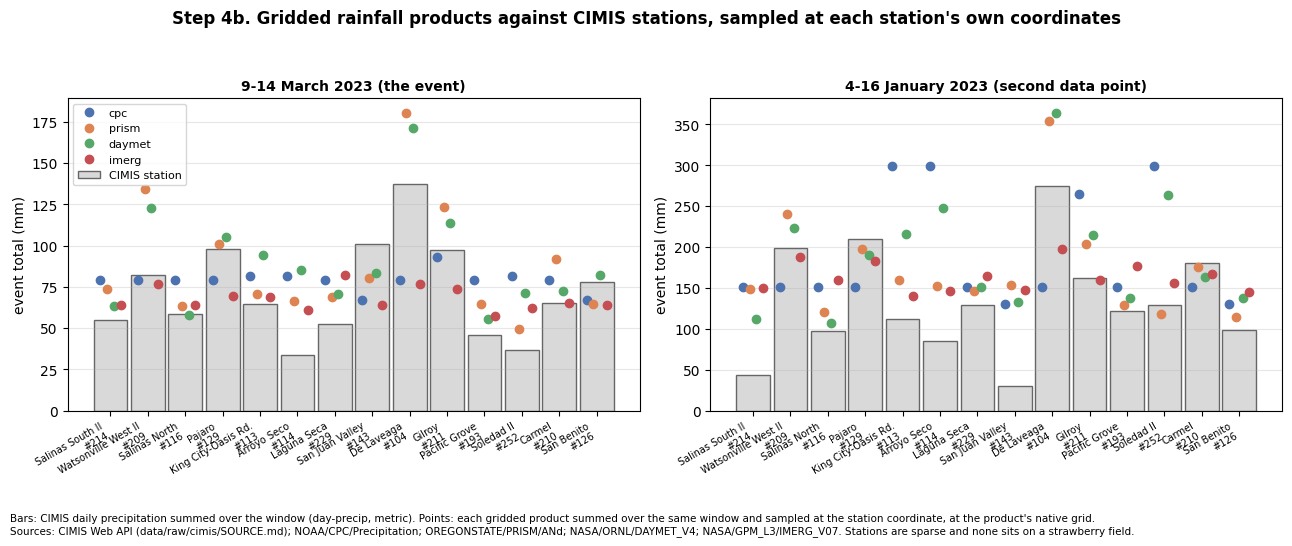

Saved supp_cimis_stations.png
n stations = 14 | date windows: 2023-03-09 to 2023-03-14; 2023-01-04 to 2023-01-16 | datasets: NOAA/CPC/Precipitation, OREGONSTATE/PRISM/ANd, NASA/ORNL/DAYMET_V4, NASA/GPM_L3/IMERG_V07; CIMIS Web API day-precip


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
colors = dict(zip(C.RAIN, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))
for ax, (suffix, scol, title) in zip(axes, [
        ("event", "station_event", "9-14 March 2023 (the event)"),
        ("jan", "station_jan", "4-16 January 2023 (second data point)")]):
    x = np.arange(len(grid))
    w = 0.18
    ax.bar(x, grid[scol], width=0.9, color="0.85", edgecolor="0.4",
           label="CIMIS station", zorder=1)
    for i, key in enumerate(C.RAIN):
        ax.plot(x + (i - 1.5) * w, grid[f"{key}_{suffix}"], "o", ms=6, color=colors[key],
                label=key, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{n}\n#{s}" for n, s in zip(grid.name, grid.station)],
                       fontsize=7, rotation=30, ha="right")
    ax.set_ylabel("event total (mm)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Step 4b. Gridded rainfall products against CIMIS stations, "
             "sampled at each station's own coordinates", fontsize=12, fontweight="bold")
fig.text(0.01, 0.01,
         "Bars: CIMIS daily precipitation summed over the window (day-precip, metric). "
         "Points: each gridded product summed over the same window and sampled at the station "
         "coordinate, at the product's native grid.\nSources: CIMIS Web API "
         "(data/raw/cimis/SOURCE.md); " + "; ".join(v[0] for v in C.RAIN.values())
         + ". Stations are sparse and none sits on a strawberry field.", fontsize=7.5)
fig.tight_layout(rect=(0, 0.07, 1, 0.94))
FIG = C.FIGURES / "supp_cimis_stations.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"n stations = {len(grid)} | date windows: {EVENT_DAYS[0]} to {EVENT_DAYS[1]}; "
      f"{JAN_DAYS[0]} to {JAN_DAYS[1]} | datasets: "
      + ", ".join(v[0] for v in C.RAIN.values()) + "; CIMIS Web API day-precip")